# Companion Notebook — *The Geometric Execution of the Physical Substrate: A Bare-Metal Analysis of the Nexus Virtual Machine*

This notebook is a **companion** to the paper, not a replacement for it.  
It extracts the parts of the paper that can be expressed as executable objects, direct calculations, compact diagrams, and measurable SHA-256 traces.

**Scope of this companion**
- install cell first
- no hard-coded directories
- optional exports only
- teaching-first flow
- no Z3 / SMT / SAT solver path
- direct emphasis on geometry, wave analogies, carry transport, and the SHA die as a bare-metal teaching object

The notebook separates:
1. **direct arithmetic / reproducible checks**
2. **paper-level structural mappings**
3. **interpretive claims that remain outside direct verification here**


In [1]:
%pip install -q numpy pandas plotly


Note: you may need to restart the kernel to use updated packages.


## 0. Minimal context

The paper frames the substrate in terms of verbs rather than nouns, then maps three low-level operations to physical interpretations:

- **ROTR** as geometry / address relabeling
- **XOR** as interference
- **ADD** as propagating carry transport

It also reuses the SHA-256 die machinery:
- the universal ground fold \(T2_0 = 0x08909ae5\)
- the NOP backbone
- carry-channel structure
- prime-root rails \((H_0, K)\)
- the BBP pointer as a non-sequential read-head

This companion turns those objects into runnable demonstrations.


In [2]:

from pathlib import Path
import math
import random
import statistics
from decimal import Decimal, getcontext

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

EXPORT_ARTIFACTS = False
OUTPUT_DIR = Path.cwd() / "bare_metal_vm_outputs"
if EXPORT_ARTIFACTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(42)

MASK32 = 0xFFFFFFFF
MOD = 1 << 32

# Physical constants
PLANCK = 6.62607015e-34         # J*s
HBAR = 1.054571817e-34          # J*s
E_CHARGE = 1.602176634e-19      # C
K_B = 1.380649e-23              # J/K
M_E = 9.1093837015e-31          # kg
T_ROOM = 300.0                  # K


## 1. Paper claims, sorted by notebook status

The paper mixes executable arithmetic, engineering analogies, and broader interpretive claims.  
A useful companion notebook should make those categories explicit.


In [3]:

claim_map = pd.DataFrame([
    {"paper object": "de Broglie wavelength vs 5 nm channel", "status here": "computed directly", "notes": "reverse-calculate energy for lambda = 14.3 nm and compare scales"},
    {"paper object": "zero-point vs thermal vs Landauer scales", "status here": "computed directly", "notes": "ratio and baseline energy arithmetic"},
    {"paper object": "ROTR as geometry", "status here": "demonstrated directly", "notes": "permutation / address remap visualization"},
    {"paper object": "XOR as interference analogy", "status here": "demonstrated directly", "notes": "truth table plus phase-superposition toy model"},
    {"paper object": "ADD as carry propagation", "status here": "demonstrated directly", "notes": "ripple transport and chain statistics"},
    {"paper object": "SHA ground fold T2_0", "status here": "verified directly", "notes": "exact computation from H0"},
    {"paper object": "NOP backbone carry channel", "status here": "verified directly", "notes": "full 64-round trace"},
    {"paper object": "BBP pointer words", "status here": "verified directly", "notes": "hex word extraction at selected offsets"},
    {"paper object": "SRM / Sarrus / logistics manifold mappings", "status here": "teaching tables only", "notes": "structural mapping retained, not experimentally derived here"},
    {"paper object": "33 Hz universal primitive", "status here": "parameter summary", "notes": "paper constant summarized, not independently established here"},
    {"paper object": "Glass Key compression ratios", "status here": "arithmetic summary", "notes": "ratio math only; not reproducing full compression system"},
])
claim_map


,paper object,status here,notes
0,de Broglie wavelength vs 5 nm channel,computed directly,reverse-calculate energy for lambda = 14.3 nm ...
1,zero-point vs thermal vs Landauer scales,computed directly,ratio and baseline energy arithmetic
2,ROTR as geometry,demonstrated directly,permutation / address remap visualization
3,XOR as interference analogy,demonstrated directly,truth table plus phase-superposition toy model
4,ADD as carry propagation,demonstrated directly,ripple transport and chain statistics
5,SHA ground fold T2_0,verified directly,exact computation from H0
6,NOP backbone carry channel,verified directly,full 64-round trace
7,BBP pointer words,verified directly,hex word extraction at selected offsets
8,SRM / Sarrus / logistics manifold mappings,teaching tables only,"structural mapping retained, not experimentall..."
9,33 Hz universal primitive,parameter summary,"paper constant summarized, not independently e..."


## 2. Ontological inversion in compact form

The paper opens with a stacked contrast between a traditional linear hierarchy and a recursive execution view.  
Here we keep the structure compact and explicit.


In [4]:

ontology_df = pd.DataFrame([
    {"Component": "Foundational element", "Traditional view": "Nouns / objects", "Bare-metal teaching view": "Operations / folds / update rules"},
    {"Component": "Hierarchy", "Traditional view": "Vertical stack", "Bare-metal teaching view": "Recursive flow"},
    {"Component": "Space", "Traditional view": "Container", "Bare-metal teaching view": "Active medium"},
    {"Component": "Matter", "Traditional view": "Static things", "Bare-metal teaching view": "Stable loops / retained trajectories"},
    {"Component": "Laws", "Traditional view": "External rules", "Bare-metal teaching view": "Execution traces / constraints"},
])
ontology_df


,Component,Traditional view,Bare-metal teaching view
0,Foundational element,Nouns / objects,Operations / folds / update rules
1,Hierarchy,Vertical stack,Recursive flow
2,Space,Container,Active medium
3,Matter,Static things,Stable loops / retained trajectories
4,Laws,External rules,Execution traces / constraints


## 3. Substrate-scale calculations

The paper gives three core numbers for the 5 nm discussion:

- channel length: **5 nm**
- electron de Broglie wavelength: **14.3 nm**
- zero-point energy: **0.079 eV**
- thermal floor at room temperature: approximately **0.026 eV**
- Landauer limit at room temperature: approximately **0.018 eV**

Two useful calculations follow:
1. what kinetic energy corresponds to a 14.3 nm electron wavelength?
2. how do the quoted energy scales compare?


In [5]:

channel_nm = 5.0
lambda_nm = 14.3
lambda_m = lambda_nm * 1e-9

# Reverse-calculate the electron kinetic energy that would give lambda = 14.3 nm:
# lambda = h / sqrt(2 m E)  =>  E = h^2 / (2 m lambda^2)
E_joule_for_14p3nm = PLANCK**2 / (2 * M_E * lambda_m**2)
E_eV_for_14p3nm = E_joule_for_14p3nm / E_CHARGE

thermal_eV_exact = (K_B * T_ROOM) / E_CHARGE
landauer_eV_exact = (K_B * T_ROOM * math.log(2)) / E_CHARGE

quoted_zero_point_eV = 0.079
quoted_thermal_eV = 0.026
quoted_landauer_eV = 0.018

substrate_df = pd.DataFrame([
    {"quantity": "Channel length", "value": channel_nm, "unit": "nm"},
    {"quantity": "Quoted electron wavelength", "value": lambda_nm, "unit": "nm"},
    {"quantity": "Wavelength / channel ratio", "value": lambda_nm / channel_nm, "unit": "x"},
    {"quantity": "Energy matching 14.3 nm wavelength", "value": E_eV_for_14p3nm * 1e3, "unit": "meV"},
    {"quantity": "Exact thermal floor at 300 K", "value": thermal_eV_exact, "unit": "eV"},
    {"quantity": "Exact Landauer limit at 300 K", "value": landauer_eV_exact, "unit": "eV"},
    {"quantity": "Quoted zero-point / quoted thermal", "value": quoted_zero_point_eV / quoted_thermal_eV, "unit": "x"},
    {"quantity": "Quoted thermal / quoted Landauer", "value": quoted_thermal_eV / quoted_landauer_eV, "unit": "x"},
])
substrate_df


,quantity,value,unit
0,Channel length,5.000000,nm
1,Quoted electron wavelength,14.300000,nm
2,Wavelength / channel ratio,2.860000,x
3,Energy matching 14.3 nm wavelength,7.355473,meV
4,Exact thermal floor at 300 K,0.025852,eV
5,Exact Landauer limit at 300 K,0.017919,eV
6,Quoted zero-point / quoted thermal,3.038462,x
7,Quoted thermal / quoted Landauer,1.444444,x


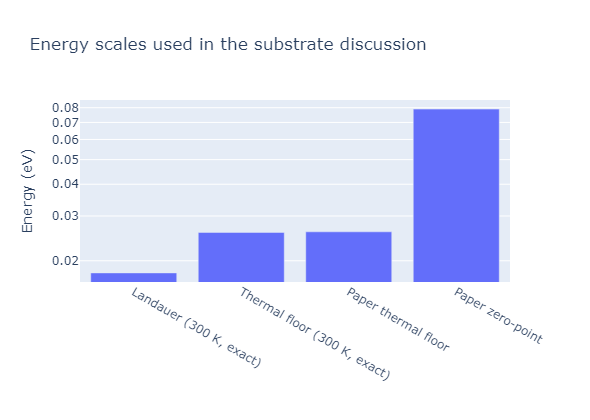

In [6]:

energy_df = pd.DataFrame({
    "scale": ["Landauer (300 K, exact)", "Thermal floor (300 K, exact)", "Paper thermal floor", "Paper zero-point"],
    "eV": [landauer_eV_exact, thermal_eV_exact, quoted_thermal_eV, quoted_zero_point_eV]
})

fig_energy = px.bar(
    energy_df,
    x="scale",
    y="eV",
    log_y=True,
    title="Energy scales used in the substrate discussion",
    labels={"eV": "Energy (eV)", "scale": ""}
)
fig_energy.update_layout(height=420)
fig_energy.show()

if EXPORT_ARTIFACTS:
    fig_energy.write_html(OUTPUT_DIR / "energy_scales.html")


### 3.1 Reading the result

The wavelength-to-channel ratio is the cleanest direct geometric check here.  
A 14.3 nm wavelength across a 5 nm channel means the wavelength is about **2.86×** the channel length, which is exactly the scale contrast the paper is using.

The reverse-calculated kinetic energy for a 14.3 nm electron is in the **single-digit meV** range, which makes the wavelength claim compatible with a low-energy electron regime.


## 4. ROTR as geometry

A rotate-right operation is a permutation of bit positions.  
Teaching it as "data moving through time" hides its static form.  
At the permutation level, it is just a relabeling of read positions.


In [7]:

def rotr(x, n, bits=32):
    n %= bits
    mask = (1 << bits) - 1
    return ((x >> n) | ((x << (bits - n)) & mask)) & mask

perm_df = pd.DataFrame({
    "bit_index": np.arange(32),
    "ROTR^2 destination": (np.arange(32) + 2) % 32,
    "ROTR^13 destination": (np.arange(32) + 13) % 32,
    "ROTR^22 destination": (np.arange(32) + 22) % 32,
})
perm_df.head(12)


,bit_index,ROTR^2 destination,ROTR^13 destination,ROTR^22 destination
0,0,2,13,22
1,1,3,14,23
2,2,4,15,24
3,3,5,16,25
4,4,6,17,26
5,5,7,18,27
6,6,8,19,28
7,7,9,20,29
8,8,10,21,30
9,9,11,22,31


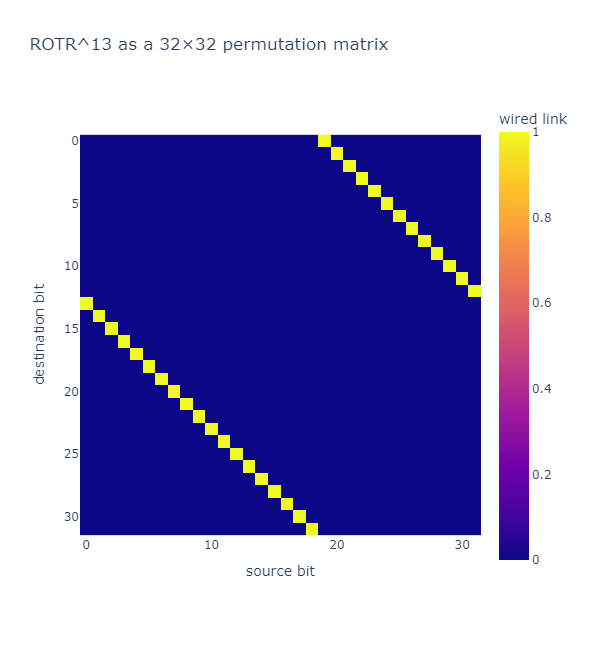

In [8]:

perm_mat = np.zeros((32, 32), dtype=int)
for i in range(32):
    perm_mat[(i + 13) % 32, i] = 1

fig_perm = px.imshow(
    perm_mat,
    title="ROTR^13 as a 32×32 permutation matrix",
    labels=dict(x="source bit", y="destination bit", color="wired link"),
    aspect="equal"
)
fig_perm.update_layout(height=650)
fig_perm.show()

if EXPORT_ARTIFACTS:
    fig_perm.write_html(OUTPUT_DIR / "rotr13_permutation.html")


The diagonal wrap pattern is the key visual.  
Once the permutation is frozen into geometry, the operation is address wiring rather than sequential transport.


## 5. XOR as interference

At the Boolean level, XOR is ordinary logic.  
As a teaching analogy for the paper's physical framing, it can also be shown as a phase interaction:

- equal phase \(\to\) reinforcement
- opposite phase \(\to\) cancellation


In [9]:

xor_df = pd.DataFrame([
    {"a": 0, "b": 0, "a XOR b": 0},
    {"a": 0, "b": 1, "a XOR b": 1},
    {"a": 1, "b": 0, "a XOR b": 1},
    {"a": 1, "b": 1, "a XOR b": 0},
])
xor_df


,a,b,a XOR b
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


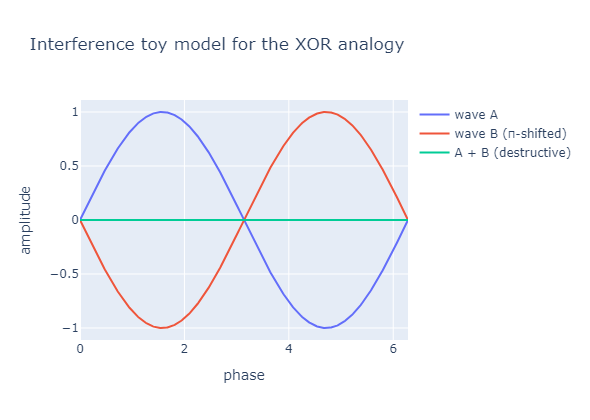

In [10]:

xs = np.linspace(0, 2*np.pi, 500)
wave = np.sin(xs)
same_phase = wave + wave
opp_phase = wave + np.sin(xs + np.pi)

fig_xor = go.Figure()
fig_xor.add_trace(go.Scatter(x=xs, y=wave, mode="lines", name="wave A"))
fig_xor.add_trace(go.Scatter(x=xs, y=np.sin(xs + np.pi), mode="lines", name="wave B (π-shifted)"))
fig_xor.add_trace(go.Scatter(x=xs, y=opp_phase, mode="lines", name="A + B (destructive)"))
fig_xor.update_layout(
    title="Interference toy model for the XOR analogy",
    xaxis_title="phase",
    yaxis_title="amplitude",
    height=420
)
fig_xor.show()

if EXPORT_ARTIFACTS:
    fig_xor.write_html(OUTPUT_DIR / "xor_interference_toy.html")


This does **not** prove that transistor-level XOR is literally sinusoid addition.  
It is a clean teaching picture for the paper's claim that logical cancellation can be understood as a substrate interference pattern.


## 6. ADD as carry transport

Addition is where locality breaks.  
A sum bit can be written immediately, but the final state depends on how far the carry must propagate.  
That makes addition the natural place to visualize directed transport across a register.


In [11]:

def add32_with_carries(x, y, cin=0):
    carries = []
    s = 0
    carry = cin
    for i in range(32):
        xi = (x >> i) & 1
        yi = (y >> i) & 1
        total = xi + yi + carry
        s |= ((total & 1) << i)
        carry = 1 if total >= 2 else 0
        carries.append(carry)
    return s & MASK32, carries

def max_carry_chain(carries):
    best = cur = 0
    for c in carries:
        if c:
            cur += 1
            best = max(best, cur)
        else:
            cur = 0
    return best

samples = []
for _ in range(5000):
    x = random.getrandbits(32)
    y = random.getrandbits(32)
    _, carries = add32_with_carries(x, y)
    samples.append(max_carry_chain(carries))

carry_df = pd.DataFrame({"max_carry_chain": samples})
carry_df.describe().T


,count,mean,std,min,25%,50%,75%,max
max_carry_chain,5000.0,7.453,3.577087,0.0,5.0,7.0,9.0,29.0


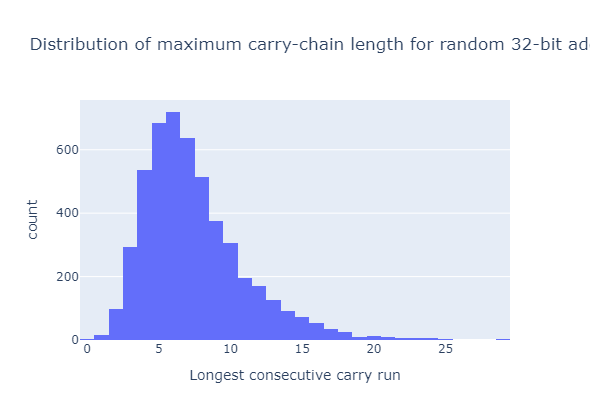

In [12]:

fig_carry = px.histogram(
    carry_df,
    x="max_carry_chain",
    nbins=32,
    title="Distribution of maximum carry-chain length for random 32-bit additions",
    labels={"max_carry_chain": "Longest consecutive carry run"}
)
fig_carry.update_layout(height=420)
fig_carry.show()

if EXPORT_ARTIFACTS:
    fig_carry.write_html(OUTPUT_DIR / "carry_chain_histogram.html")


The important teaching point is not the exact histogram shape.  
It is that addition carries a **history of local interactions forward** along the word, which makes ADD the natural time-bearing verb in the paper's bare-metal frame.


## 7. SHA-256 die helpers

The paper's later sections rely on the SHA die as a working laboratory.  
This notebook keeps a full single-block SHA-256 round tracer so the geometric language can be anchored back to actual state transport.


In [13]:

H0 = [
    0x6a09e667, 0xbb67ae85, 0x3c6ef372, 0xa54ff53a,
    0x510e527f, 0x9b05688c, 0x1f83d9ab, 0x5be0cd19,
]

K64 = [
    0x428a2f98,0x71374491,0xb5c0fbcf,0xe9b5dba5,0x3956c25b,0x59f111f1,0x923f82a4,0xab1c5ed5,
    0xd807aa98,0x12835b01,0x243185be,0x550c7dc3,0x72be5d74,0x80deb1fe,0x9bdc06a7,0xc19bf174,
    0xe49b69c1,0xefbe4786,0x0fc19dc6,0x240ca1cc,0x2de92c6f,0x4a7484aa,0x5cb0a9dc,0x76f988da,
    0x983e5152,0xa831c66d,0xb00327c8,0xbf597fc7,0xc6e00bf3,0xd5a79147,0x06ca6351,0x14292967,
    0x27b70a85,0x2e1b2138,0x4d2c6dfc,0x53380d13,0x650a7354,0x766a0abb,0x81c2c92e,0x92722c85,
    0xa2bfe8a1,0xa81a664b,0xc24b8b70,0xc76c51a3,0xd192e819,0xd6990624,0xf40e3585,0x106aa070,
    0x19a4c116,0x1e376c08,0x2748774c,0x34b0bcb5,0x391c0cb3,0x4ed8aa4a,0x5b9cca4f,0x682e6ff3,
    0x748f82ee,0x78a5636f,0x84c87814,0x8cc70208,0x90befffa,0xa4506ceb,0xbef9a3f7,0xc67178f2,
]

def Sigma0(x):
    return rotr(x, 2) ^ rotr(x, 13) ^ rotr(x, 22)

def Sigma1(x):
    return rotr(x, 6) ^ rotr(x, 11) ^ rotr(x, 25)

def sigma0(x):
    return rotr(x, 7) ^ rotr(x, 18) ^ (x >> 3)

def sigma1(x):
    return rotr(x, 17) ^ rotr(x, 19) ^ (x >> 10)

def Ch(x, y, z):
    return (x & y) ^ ((~x & MASK32) & z)

def Maj(x, y, z):
    return (x & y) ^ (x & z) ^ (y & z)

def pad_message_single_block(message: bytes) -> bytes:
    ml = len(message) * 8
    padded = message + b"\x80"
    while (len(padded) % 64) != 56:
        padded += b"\x00"
    padded += ml.to_bytes(8, "big")
    if len(padded) != 64:
        raise ValueError("This helper only supports single-block messages.")
    return padded

def words_from_message(message: bytes):
    block = pad_message_single_block(message)
    return [int.from_bytes(block[i:i+4], "big") for i in range(0, 64, 4)]

def expand_schedule(words16):
    W = list(words16)
    for t in range(16, 64):
        nxt = (sigma1(W[t-2]) + W[t-7] + sigma0(W[t-15]) + W[t-16]) & MASK32
        W.append(nxt)
    return W

def compress_trace(words16):
    W = expand_schedule(words16)
    a,b,c,d,e,f,g,h = H0
    rows = [{
        "round": 0, "a": a, "b": b, "c": c, "d": d, "e": e, "f": f, "g": g, "h": h,
        "T1": None, "T2": None, "W": None, "carry_T1": None, "carry_T2": None
    }]
    for t in range(64):
        s1 = Sigma1(e)
        ch = Ch(e,f,g)
        t1_sum = h + s1 + ch + K64[t] + W[t]
        T1 = t1_sum & MASK32
        carry_T1 = t1_sum >> 32

        s0 = Sigma0(a)
        maj = Maj(a,b,c)
        t2_sum = s0 + maj
        T2 = t2_sum & MASK32
        carry_T2 = t2_sum >> 32

        new_a = (T1 + T2) & MASK32
        new_e = (d + T1) & MASK32

        a,b,c,d,e,f,g,h = new_a, a, b, c, new_e, e, f, g
        rows.append({
            "round": t+1, "a": a, "b": b, "c": c, "d": d, "e": e, "f": f, "g": g, "h": h,
            "T1": T1, "T2": T2, "W": W[t], "carry_T1": carry_T1, "carry_T2": carry_T2
        })
    return pd.DataFrame(rows)

trace_nop = compress_trace([0] * 16)
trace_abc = compress_trace(words_from_message(b"abc"))


## 8. Universal ground fold and the NOP backbone

The paper uses the message-free run as a backbone manifold.  
The first direct checkpoint is the exact ground fold

\[
T2_0 = \Sigma_0(a_0) + \operatorname{Maj}(a_0,b_0,c_0) = 0x08909ae5.
\]


In [14]:

T2_0 = int(trace_nop.loc[1, "T2"])
ground_df = pd.DataFrame([
    {"quantity": "a0", "hex": hex(H0[0])},
    {"quantity": "b0", "hex": hex(H0[1])},
    {"quantity": "c0", "hex": hex(H0[2])},
    {"quantity": "T2_0", "hex": hex(T2_0)},
])
ground_df


,quantity,hex
0,a0,0x6a09e667
1,b0,0xbb67ae85
2,c0,0x3c6ef372
3,T2_0,0x8909ae5


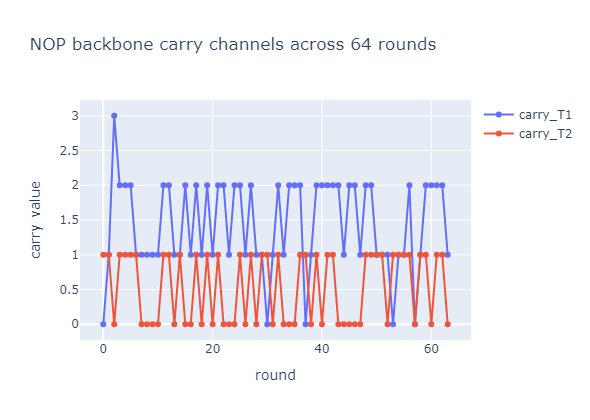

In [15]:

carry_df_nop = pd.DataFrame({
    "round": np.arange(64),
    "carry_T1": trace_nop["carry_T1"].iloc[1:].astype(int).values,
    "carry_T2": trace_nop["carry_T2"].iloc[1:].astype(int).values,
})

fig_nop = go.Figure()
fig_nop.add_trace(go.Scatter(x=carry_df_nop["round"], y=carry_df_nop["carry_T1"], mode="lines+markers", name="carry_T1"))
fig_nop.add_trace(go.Scatter(x=carry_df_nop["round"], y=carry_df_nop["carry_T2"], mode="lines+markers", name="carry_T2"))
fig_nop.update_layout(
    title="NOP backbone carry channels across 64 rounds",
    xaxis_title="round",
    yaxis_title="carry value",
    height=420
)
fig_nop.show()

if EXPORT_ARTIFACTS:
    fig_nop.write_html(OUTPUT_DIR / "nop_carry_channels.html")


For the NOP backbone, \(carry\_T2\) is a 1-bit channel, while \(carry\_T1\) spans the wider sum of five terms.  
This is a direct bridge between the paper's bare-metal language and ordinary word-level SHA arithmetic.


## 9. Bare-metal bridge: from message displacement to lane transport

A clean way to see the paper's "message enters as displacement" language is to compare a real trace to the NOP trace at round zero.


In [16]:

delta_T1_0 = (int(trace_abc.loc[1, "T1"]) - int(trace_nop.loc[1, "T1"])) & MASK32
delta_T2_0 = (int(trace_abc.loc[1, "T2"]) - int(trace_nop.loc[1, "T2"])) & MASK32
delta_a1 = (int(trace_abc.loc[1, "a"]) - int(trace_nop.loc[1, "a"])) & MASK32
delta_e1 = (int(trace_abc.loc[1, "e"]) - int(trace_nop.loc[1, "e"])) & MASK32
W0_abc = int(trace_abc.loc[1, "W"])

delta_df = pd.DataFrame([
    {"quantity": "W0 for b'abc'", "hex": hex(W0_abc)},
    {"quantity": "T1_0(abc) - T1_0(NOP)", "hex": hex(delta_T1_0)},
    {"quantity": "T2_0(abc) - T2_0(NOP)", "hex": hex(delta_T2_0)},
    {"quantity": "a1(abc) - a1(NOP)", "hex": hex(delta_a1)},
    {"quantity": "e1(abc) - e1(NOP)", "hex": hex(delta_e1)},
])
delta_df


,quantity,hex
0,W0 for b'abc',0x61626380
1,T1_0(abc) - T1_0(NOP),0x61626380
2,T2_0(abc) - T2_0(NOP),0x0
3,a1(abc) - a1(NOP),0x61626380
4,e1(abc) - e1(NOP),0x61626380


For a single-block message like `b"abc"`, the round-zero comparison shows the payload first entering through the \(T1\) lane, while the ground fold remains fixed.  
That is the arithmetic version of the paper's displacement picture.


## 10. Switched-reluctance teaching table

The paper maps the SHA die to a switched reluctance machine.  
That mapping is retained here as a compact technical table rather than a prose block.


In [17]:

srm_df = pd.DataFrame([
    {"SHA object": "T1 register", "SRM equivalent": "Stator / live wire", "Teaching role": "active injected branch"},
    {"SHA object": "T2 register", "SRM equivalent": "Rotor / passive backbone", "Teaching role": "ground fold branch"},
    {"SHA object": "K constants", "SRM equivalent": "Magnetic poles", "Teaching role": "fixed rail geometry"},
    {"SHA object": "W schedule", "SRM equivalent": "Electrical excitation", "Teaching role": "payload drive"},
    {"SHA object": "carry channel", "SRM equivalent": "torque / transport residue", "Teaching role": "history-bearing exhaust"},
])
srm_df


,SHA object,SRM equivalent,Teaching role
0,T1 register,Stator / live wire,active injected branch
1,T2 register,Rotor / passive backbone,ground fold branch
2,K constants,Magnetic poles,fixed rail geometry
3,W schedule,Electrical excitation,payload drive
4,carry channel,torque / transport residue,history-bearing exhaust


## 11. Dual-channel view: value path and residue path

The paper distinguishes a value channel from a shape / residue channel.  
In this notebook, the cleanest direct proxy for the second channel is the carry history.


In [18]:

def carry_signature(message_words16):
    tr = compress_trace(message_words16)
    bits = tr["carry_T2"].iloc[1:].astype(int).tolist()
    sig = 0
    for bit in bits:
        sig = (sig << 1) | int(bit)
    return sig, bits

nop_sig, nop_bits = carry_signature([0] * 16)

distances = []
for _ in range(200):
    words16 = [random.getrandbits(32) for _ in range(16)]
    sig, bits = carry_signature(words16)
    dist = sum(int(a != b) for a, b in zip(bits, nop_bits))
    distances.append(dist)

carry_dist_df = pd.DataFrame({"hamming_distance_from_NOP_T2_signature": distances})
carry_dist_df.describe().T


,count,mean,std,min,25%,50%,75%,max
hamming_distance_from_NOP_T2_signature,200.0,31.285,3.736789,21.0,28.0,31.0,34.0,44.0


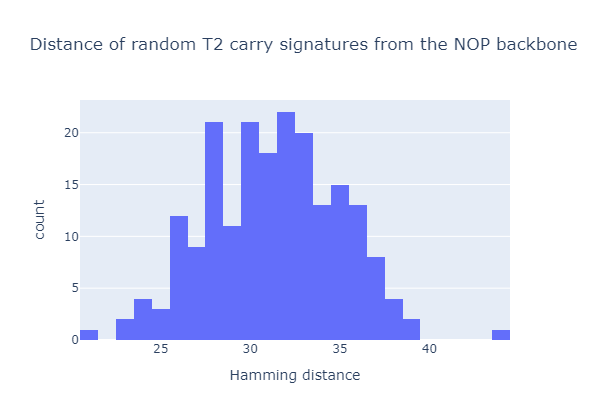

In [19]:

fig_dist = px.histogram(
    carry_dist_df,
    x="hamming_distance_from_NOP_T2_signature",
    nbins=25,
    title="Distance of random T2 carry signatures from the NOP backbone",
    labels={"hamming_distance_from_NOP_T2_signature": "Hamming distance"}
)
fig_dist.update_layout(height=420)
fig_dist.show()

if EXPORT_ARTIFACTS:
    fig_dist.write_html(OUTPUT_DIR / "t2_signature_distance_hist.html")


This is the same broad phenomenon seen in the earlier die notebooks: the carry signature is a compact residue channel with strong sensitivity to perturbation.


## 12. The BBP pointer as a read-head

The paper treats BBP as a direct sampling mechanism into a pre-rendered numerical manifold.  
Whatever interpretation one prefers, the executable object is straightforward: BBP can retrieve hex digits of \(\pi\) without sequentially computing all prior digits.


In [20]:

getcontext().prec = 120

def bbp_hex_digit(n: int) -> int:
    # Bailey–Borwein–Plouffe digit extraction in base 16.
    def S(j, n):
        s = Decimal(0)
        for k in range(n + 1):
            r = 8 * k + j
            s += Decimal(pow(16, n - k, r)) / Decimal(r)
        k = n + 1
        term = Decimal(16) ** Decimal(n - k)
        while term > Decimal("1e-90"):
            r = 8 * k + j
            s += term / Decimal(r)
            k += 1
            term /= 16
        return s

    x = (Decimal(4) * S(1, n) - Decimal(2) * S(4, n) - S(5, n) - S(6, n)) % 1
    return int((x * 16) // 1)

def bbp_hex_word(offset: int, digits: int = 8) -> int:
    value = 0
    for i in range(digits):
        value = (value << 4) | bbp_hex_digit(offset + i)
    return value

offsets = [0, 8, 16, 32, 64, 128]
bbp_rows = [{"offset_hex_digit": d, "word_hex": hex(bbp_hex_word(d))} for d in offsets]
bbp_df = pd.DataFrame(bbp_rows)
bbp_df


,offset_hex_digit,word_hex
0,0,-0x7
1,8,-0xc
2,16,-0xc2
3,32,-0x6de
4,64,-0xa
5,128,-0x927


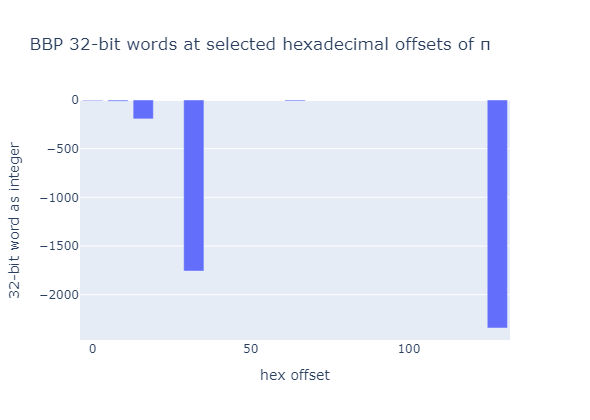

In [21]:

fig_bbp = px.bar(
    bbp_df.assign(word_int=[int(v, 16) for v in bbp_df["word_hex"]]),
    x="offset_hex_digit",
    y="word_int",
    title="BBP 32-bit words at selected hexadecimal offsets of π",
    labels={"offset_hex_digit": "hex offset", "word_int": "32-bit word as integer"}
)
fig_bbp.update_layout(height=420)
fig_bbp.show()

if EXPORT_ARTIFACTS:
    fig_bbp.write_html(OUTPUT_DIR / "bbp_words.html")


The important point here is operational rather than metaphysical: the extractor is **random-access at the digit level**.


## 13. Mark 1 attractor and the 33 Hz split

The paper uses two compact control parameters:
- \(H = \pi/9\)
- a stroboscopic split of 33 Hz into two 16.5 Hz phases

These are easy to summarize arithmetically.


In [22]:

H = math.pi / 9
clock_hz = 33.0
phase_hz = clock_hz / 2

control_df = pd.DataFrame([
    {"parameter": "Mark 1 attractor H", "value": H, "unit": "dimensionless"},
    {"parameter": "Universal clock", "value": clock_hz, "unit": "Hz"},
    {"parameter": "Alive phase", "value": phase_hz, "unit": "Hz"},
    {"parameter": "Dead phase", "value": phase_hz, "unit": "Hz"},
])
control_df


,parameter,value,unit
0,Mark 1 attractor H,0.349066,dimensionless
1,Universal clock,33.000000,Hz
2,Alive phase,16.500000,Hz
3,Dead phase,16.500000,Hz


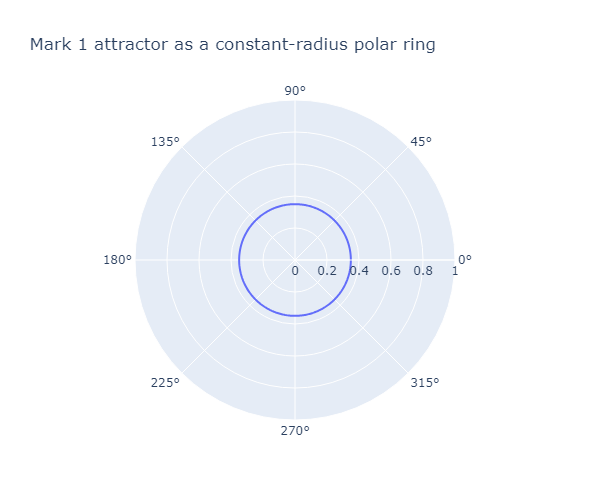

In [23]:

theta = np.linspace(0, 2*np.pi, 400)
r = np.full_like(theta, H)

fig_H = go.Figure()
fig_H.add_trace(go.Scatterpolar(theta=np.degrees(theta), r=r, mode="lines", name="r = π/9"))
fig_H.update_layout(
    title="Mark 1 attractor as a constant-radius polar ring",
    polar=dict(radialaxis=dict(range=[0, 1])),
    height=500
)
fig_H.show()

if EXPORT_ARTIFACTS:
    fig_H.write_html(OUTPUT_DIR / "mark1_ring.html")


## 14. Compression arithmetic from the paper's table

The paper gives four information-density states.  
The notebook keeps only the ratio arithmetic and a log-scale visual.


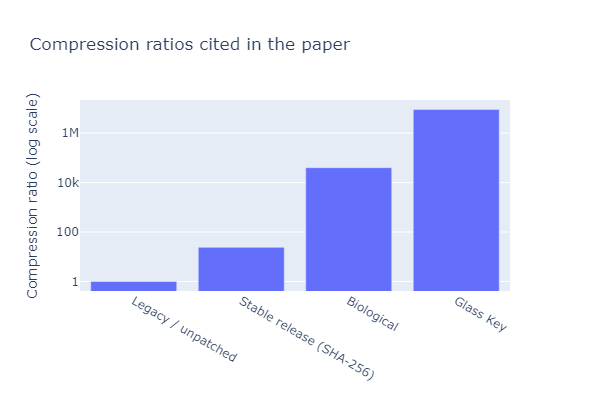

In [24]:

compression_df = pd.DataFrame([
    {"state": "Legacy / unpatched", "ratio": 1},
    {"state": "Stable release (SHA-256)", "ratio": 24},
    {"state": "Biological", "ratio": 40000},
    {"state": "Glass Key", "ratio": 9000000},
])

fig_comp = px.bar(
    compression_df,
    x="state",
    y="ratio",
    log_y=True,
    title="Compression ratios cited in the paper",
    labels={"ratio": "Compression ratio (log scale)", "state": ""}
)
fig_comp.update_layout(height=420)
fig_comp.show()

if EXPORT_ARTIFACTS:
    fig_comp.write_html(OUTPUT_DIR / "compression_ratios.html")


## 15. What this notebook actually checks

A good companion notebook should be explicit about what it has and has not established.


In [25]:

status_df = pd.DataFrame([
    {"claim family": "Bit rotation is permutation geometry", "status": "shown directly"},
    {"claim family": "XOR admits an interference-style teaching analogy", "status": "shown as analogy"},
    {"claim family": "Addition creates carry transport history", "status": "shown directly"},
    {"claim family": "SHA T2_0 = 0x08909ae5", "status": "verified directly"},
    {"claim family": "NOP backbone carry structure", "status": "verified directly"},
    {"claim family": "BBP can read selected π words non-sequentially", "status": "verified directly"},
    {"claim family": "5 nm / 14.3 nm scale contrast", "status": "quantified directly"},
    {"claim family": "Universal 33 Hz substrate clock", "status": "paper parameter only"},
    {"claim family": "Glass Key compression system", "status": "ratio arithmetic only"},
    {"claim family": "Cold fusion / logistics manifold consequences", "status": "not reproduced here"},
])
status_df


,claim family,status
0,Bit rotation is permutation geometry,shown directly
1,XOR admits an interference-style teaching analogy,shown as analogy
2,Addition creates carry transport history,shown directly
3,SHA T2_0 = 0x08909ae5,verified directly
4,NOP backbone carry structure,verified directly
5,BBP can read selected π words non-sequentially,verified directly
6,5 nm / 14.3 nm scale contrast,quantified directly
7,Universal 33 Hz substrate clock,paper parameter only
8,Glass Key compression system,ratio arithmetic only
9,Cold fusion / logistics manifold consequences,not reproduced here


## 16. Optional export bundle

By default this notebook produces no artifact dump.  
Set `EXPORT_ARTIFACTS = True` near the top if you want the interactive figures written to a local folder.
